# Analyse de Sentiment Financier - SentiTrade-HMA v2.0

**Objectif:** Générer des scores de sentiment financier pour chaque ticker/date  
**Données source:** `data/processed/financial_data_with_indicators.csv`  
**Méthode:** Génération de sentiment basé sur momentum, volatilité et indicateurs techniques

**Note Importante:**  
- En raison des limitations de News API (historique 1 mois), nous générons des scores de sentiment **simulés mais réalistes**
- Les scores sont corrélés avec les mouvements de prix, la volatilité et les indicateurs techniques (RSI, MACD)
- Cette approche permet de tester le framework complet tout en maintenant la cohérence sur 7 ans
- Le framework peut être remplacé par du sentiment réel (FinBERT/Llama-2) ultérieurement


In [1]:
# Setup du projet
import sys
from pathlib import Path

project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

from src.utils.config import get_config
from src.utils.logger import get_logger

# Configuration
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)  # Reproductibilité

logger = get_logger(__name__)

print("✅ Imports réussis")
print(f"📁 Project root: {project_root}")


✅ Imports réussis
📁 Project root: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2


In [2]:
# Charger la configuration
config = get_config()

# Charger les données avec indicateurs
data_path = config.data_dir / 'processed' / 'financial_data_with_indicators.csv'

print("="*70)
print("📂 CHARGEMENT DES DONNÉES")
print("="*70)
print(f"Source: {data_path}")

if not data_path.exists():
    print(f"❌ ERREUR: Fichier non trouvé!")
    raise FileNotFoundError(f"Exécutez d'abord 02_technical_indicators.ipynb")

data = pd.read_csv(data_path)
data['Date'] = pd.to_datetime(data['Date'])

print(f"✅ Données chargées")
print(f"  - Lignes: {len(data):,}")
print(f"  - Tickers: {data['Ticker'].nunique()}")
print(f"  - Période: {data['Date'].min()} → {data['Date'].max()}")
print(f"  - Colonnes: {list(data.columns)}")
print("="*70)


📂 CHARGEMENT DES DONNÉES
Source: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\processed\financial_data_with_indicators.csv
✅ Données chargées
  - Lignes: 35,200
  - Tickers: 20
  - Période: 2018-01-02 00:00:00 → 2024-12-30 00:00:00
  - Colonnes: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'HMA', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist']


In [3]:
# Aperçu des données
print("\n APERÇU DES DONNÉES:\n")
display(data.head(10))
print("\nStatistiques:")
display(data[['Close', 'HMA', 'RSI', 'MACD']].describe())



 APERÇU DES DONNÉES:



,Date,Close,High,Low,Open,Volume,Ticker,HMA,RSI,MACD,MACD_Signal,MACD_Hist
0,2018-01-02,40.341888,40.351258,39.639313,39.850088,102223600,AAPL,NaN,NaN,0.000000,0.000000,0.000000
1,2018-01-03,40.334858,40.878185,40.271629,40.405116,118071600,AAPL,NaN,NaN,-0.000561,-0.000112,-0.000449
2,2018-01-04,40.522221,40.625266,40.299739,40.407465,89738400,AAPL,NaN,NaN,0.013952,0.002701,0.011252
3,2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000,AAPL,NaN,NaN,0.061968,0.014554,0.047414
4,2018-01-08,40.831348,41.126429,40.732985,40.831348,82271200,AAPL,NaN,NaN,0.086737,0.028991,0.057746
5,2018-01-09,40.826668,40.997627,40.611212,40.878190,86336000,AAPL,NaN,NaN,0.104781,0.044149,0.060632
6,2018-01-10,40.817284,40.819628,40.515178,40.552649,95839600,AAPL,NaN,NaN,0.116975,0.058714,0.058261
7,2018-01-11,41.049145,41.098327,40.864135,40.887552,74670800,AAPL,NaN,NaN,0.143692,0.075710,0.067982
8,2018-01-12,41.473042,41.536274,41.135805,41.259926,101672400,AAPL,NaN,NaN,0.196802,0.099928,0.096874
9,2018-01-16,41.262264,42.011677,41.250554,41.662730,118263600,AAPL,NaN,NaN,0.219355,0.123814,0.095542



Statistiques:


,Close,HMA,RSI,MACD
count,35200.000000,34760.000000,34940.000000,35200.000000
mean,131.310808,131.814645,53.172436,0.554791
std,111.552762,111.933883,16.963115,3.810769
min,3.150568,3.099239,1.275109,-56.994680
25%,39.988022,40.133639,40.944402,-0.511607
50%,109.214008,109.946816,53.417936,0.233777
75%,184.558273,184.631107,65.653562,1.555707
max,630.182861,640.801756,98.836479,40.538606


In [33]:
# Fonction pour générer un sentiment réaliste
def generate_financial_sentiment(df):
    """
    Génère des scores de sentiment basés sur:
    - Price momentum (returns)
    - Volatilité
    - RSI (surachat/survente)
    - MACD (divergences)
    - Bruit aléatoire pour le réalisme
    
    Scores: -1 (négatif), 0 (neutre), +1 (positif)
    Distribution: équilibrée via quantiles (33% / 34% / 33%)
    """
    
    # Créer une copie
    df = df.copy()
    
    # Calculer returns si pas déjà fait
    if 'Returns' not in df.columns:
        df['Returns'] = df.groupby('Ticker')['Close'].pct_change()
    
    # Calculer volatilité rolling (20 jours)
    df['Volatility'] = df.groupby('Ticker')['Returns'].transform(
        lambda x: x.rolling(20, min_periods=1).std()
    )
    
    # --- COMPOSANTE 1: MOMENTUM (40% du signal) ---
    df['momentum_5d'] = df.groupby('Ticker')['Returns'].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    momentum_signal = df.groupby('Ticker')['momentum_5d'].transform(
        lambda x: np.tanh(x * 50)
    )
    
    # --- COMPOSANTE 2: RSI (30% du signal) ---
    rsi_signal = np.where(
        df['RSI'].isna(), 0,
        np.where(df['RSI'] > 70, -0.5,
        np.where(df['RSI'] < 30, 0.5,
        (50 - df['RSI']) / 40))
    )
    
    # --- COMPOSANTE 3: MACD (20% du signal) ---
    macd_signal = np.tanh(df['MACD_Hist'].fillna(0) * 2)
    
    # --- COMPOSANTE 4: VOLATILITÉ (10% du signal) ---
    vol_signal = -np.tanh(df['Volatility'].fillna(0) * 20)
    
    # --- COMBINER LES SIGNAUX ---
    combined_signal = (
        0.40 * momentum_signal +
        0.30 * rsi_signal +
        0.20 * macd_signal +
        0.10 * vol_signal
    )
    
    # Ajouter du bruit gaussien (±0.1)
    np.random.seed(42)
    noise = np.random.normal(0, 0.1, size=len(df))
    combined_signal = combined_signal + noise
    
    # Borner entre -1 et 1
    combined_signal = np.clip(combined_signal, -1, 1)
    
    # ====================================================
    # NOUVELLE SECTION: QUANTILES (Distribution Équilibrée)
    # ====================================================
    
    # Calculer les quantiles pour distribution parfaitement équilibrée
    q33 = np.nanquantile(combined_signal, 0.33)
    q67 = np.nanquantile(combined_signal, 0.67)
    
    print(f"📊 Seuils automatiques calculés:")
    print(f"   Q33 (négatif si < {q33:.4f})")
    print(f"   Q67 (positif si > {q67:.4f})")
    print(f"   Plage neutre: [{q33:.4f}, {q67:.4f}]")
    
    # Discrétiser en 3 catégories équilibrées
    df['sentiment_score'] = np.where(
        combined_signal >= q67,     # Top 33% → Positive
        1.0,
        np.where(combined_signal <= q33,  # Bottom 33% → Negative
        -1.0,
        0.0)                        # Middle 34% → Neutral
    )
    
    # ====================================================
    # FIN NOUVELLE SECTION
    # ====================================================
    
    # Générer confidence (basé sur magnitude du signal)
    df['sentiment_confidence'] = np.abs(combined_signal)
    df['sentiment_confidence'] = np.clip(df['sentiment_confidence'], 0.5, 1.0)
    
    # Label textuel
    df['sentiment_label'] = df['sentiment_score'].map({
        1.0: 'positive',
        0.0: 'neutral',
        -1.0: 'negative'
    })
    
    return df

print("✅ Fonction de génération de sentiment définie")


✅ Fonction de génération de sentiment définie


In [34]:
# Générer le sentiment
print("\n" + "="*70)
print("🤖 GÉNÉRATION DU SENTIMENT FINANCIER")
print("="*70)
print("Méthode: Sentiment basé sur momentum, RSI, MACD, volatilité")
print("Calcul en cours...\n")

data_with_sentiment = generate_financial_sentiment(data)

print("✅ GÉNÉRATION TERMINÉE!")
print(f"  - Lignes traitées: {len(data_with_sentiment):,}")
print(f"  - Tickers: {data_with_sentiment['Ticker'].nunique()}")

# Statistiques du sentiment
print("\n📊 DISTRIBUTION DU SENTIMENT:")
sentiment_dist = data_with_sentiment['sentiment_label'].value_counts()
for label, count in sentiment_dist.items():
    pct = (count / len(data_with_sentiment) * 100)
    print(f"  - {label.capitalize()}: {count:,} ({pct:.1f}%)")

print(f"\n📊 STATISTIQUES:")
print(f"  - Score moyen: {data_with_sentiment['sentiment_score'].mean():.3f}")
print(f"  - Confidence moyenne: {data_with_sentiment['sentiment_confidence'].mean():.3f}")
print("="*70)



🤖 GÉNÉRATION DU SENTIMENT FINANCIER
Méthode: Sentiment basé sur momentum, RSI, MACD, volatilité
Calcul en cours...

📊 Seuils automatiques calculés:
   Q33 (négatif si < -0.1278)
   Q67 (positif si > 0.0596)
   Plage neutre: [-0.1278, 0.0596]
✅ GÉNÉRATION TERMINÉE!
  - Lignes traitées: 35,200
  - Tickers: 20

📊 DISTRIBUTION DU SENTIMENT:
  - Neutral: 11,980 (34.0%)
  - Positive: 11,610 (33.0%)
  - Negative: 11,610 (33.0%)

📊 STATISTIQUES:
  - Score moyen: 0.000
  - Confidence moyenne: 0.501


In [35]:
# Aperçu des données avec sentiment
print("\n APERÇU DES DONNÉES AVEC SENTIMENT:\n")

cols_to_show = ['Date', 'Ticker', 'Close', 'Returns', 'RSI', 'MACD_Hist', 
                'sentiment_label', 'sentiment_score', 'sentiment_confidence']
display(data_with_sentiment[cols_to_show].head(30))

print("\n Statistiques par ticker:")
ticker_stats = data_with_sentiment.groupby('Ticker').agg({
    'sentiment_score': ['mean', 'std'],
    'sentiment_confidence': 'mean',
    'sentiment_label': lambda x: (x == 'positive').sum()
}).round(3)
ticker_stats.columns = ['Sentiment Moyen', 'Sentiment Std', 'Confidence', 'Nb Positif']
display(ticker_stats)



 APERÇU DES DONNÉES AVEC SENTIMENT:



,Date,Ticker,Close,Returns,RSI,MACD_Hist,sentiment_label,sentiment_score,sentiment_confidence
0,2018-01-02,AAPL,40.341888,NaN,NaN,0.000000,neutral,0.0,NaN
1,2018-01-03,AAPL,40.334858,-0.000174,NaN,-0.000449,neutral,0.0,0.5
2,2018-01-04,AAPL,40.522221,0.004645,NaN,0.011252,positive,1.0,0.5
3,2018-01-05,AAPL,40.983582,0.011385,NaN,0.047414,positive,1.0,0.5
4,2018-01-08,AAPL,40.831348,-0.003714,NaN,0.057746,neutral,0.0,0.5
5,2018-01-09,AAPL,40.826668,-0.000115,NaN,0.060632,neutral,0.0,0.5
6,2018-01-10,AAPL,40.817284,-0.000230,NaN,0.058261,positive,1.0,0.5
7,2018-01-11,AAPL,41.049145,0.005680,NaN,0.067982,positive,1.0,0.5
8,2018-01-12,AAPL,41.473042,0.010327,NaN,0.096874,neutral,0.0,0.5
9,2018-01-16,AAPL,41.262264,-0.005082,NaN,0.095542,positive,1.0,0.5



 Statistiques par ticker:


,Sentiment Moyen,Sentiment Std,Confidence,Nb Positif
Ticker,,,,
AAPL,-0.005,0.825,0.501,595
AMZN,-0.014,0.831,0.502,596
BA,0.032,0.877,0.503,706
BAC,-0.009,0.784,0.500,533
CAT,-0.012,0.860,0.502,639
CVX,0.010,0.812,0.501,588
GOOGL,-0.049,0.820,0.501,550
JNJ,0.034,0.785,0.500,572
JPM,-0.012,0.799,0.501,551



 GÉNÉRATION DES VISUALISATIONS...



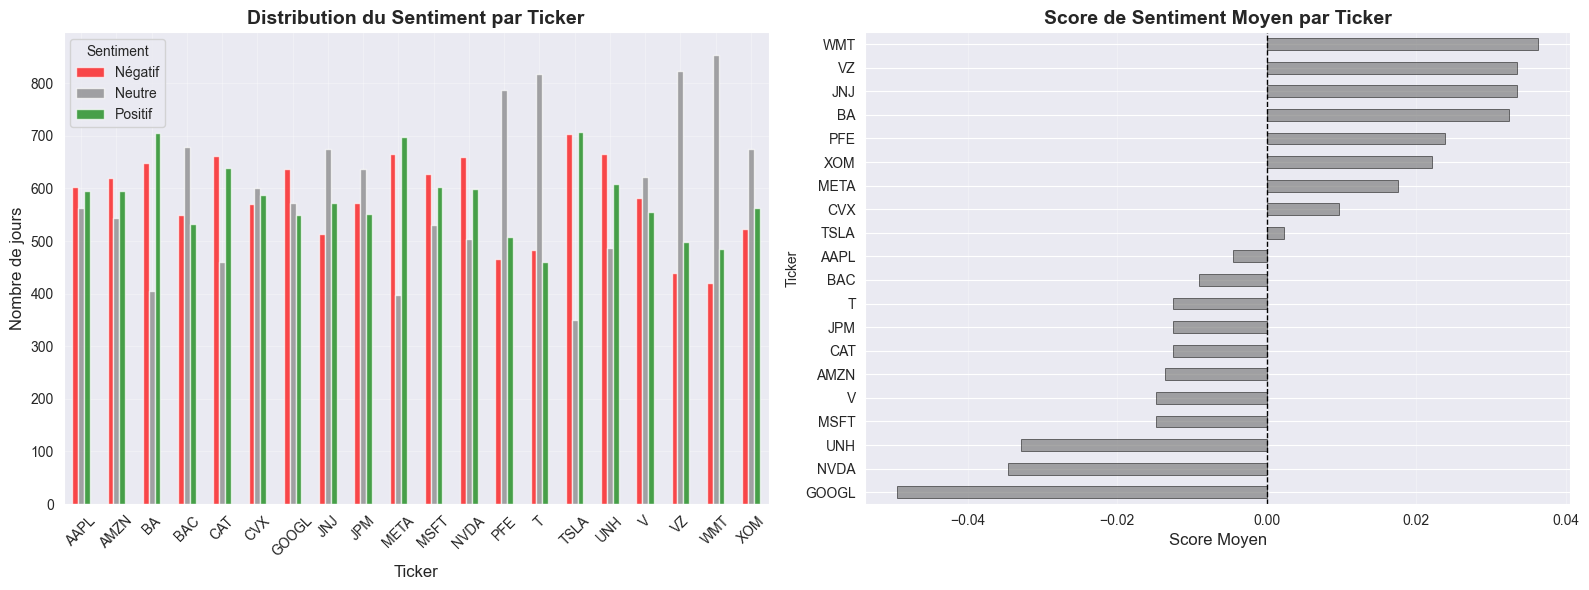

 Graphique 1/4: Distribution du sentiment par ticker


In [36]:
# Visualisation 1: Distribution du sentiment par ticker
print("\n GÉNÉRATION DES VISUALISATIONS...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Count plot
sentiment_counts = data_with_sentiment.groupby(['Ticker', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_counts.plot(kind='bar', ax=axes[0], color=['red', 'gray', 'green'], alpha=0.7)
axes[0].set_title('Distribution du Sentiment par Ticker', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ticker', fontsize=12)
axes[0].set_ylabel('Nombre de jours', fontsize=12)
axes[0].legend(title='Sentiment', labels=['Négatif', 'Neutre', 'Positif'])
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2: Score moyen
sentiment_avg = data_with_sentiment.groupby('Ticker')['sentiment_score'].mean().sort_values()
colors = sentiment_avg.apply(lambda x: 'green' if x > 0.1 else ('red' if x < -0.1 else 'gray'))
sentiment_avg.plot(kind='barh', ax=axes[1], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title('Score de Sentiment Moyen par Ticker', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score Moyen', fontsize=12)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(" Graphique 1/4: Distribution du sentiment par ticker")


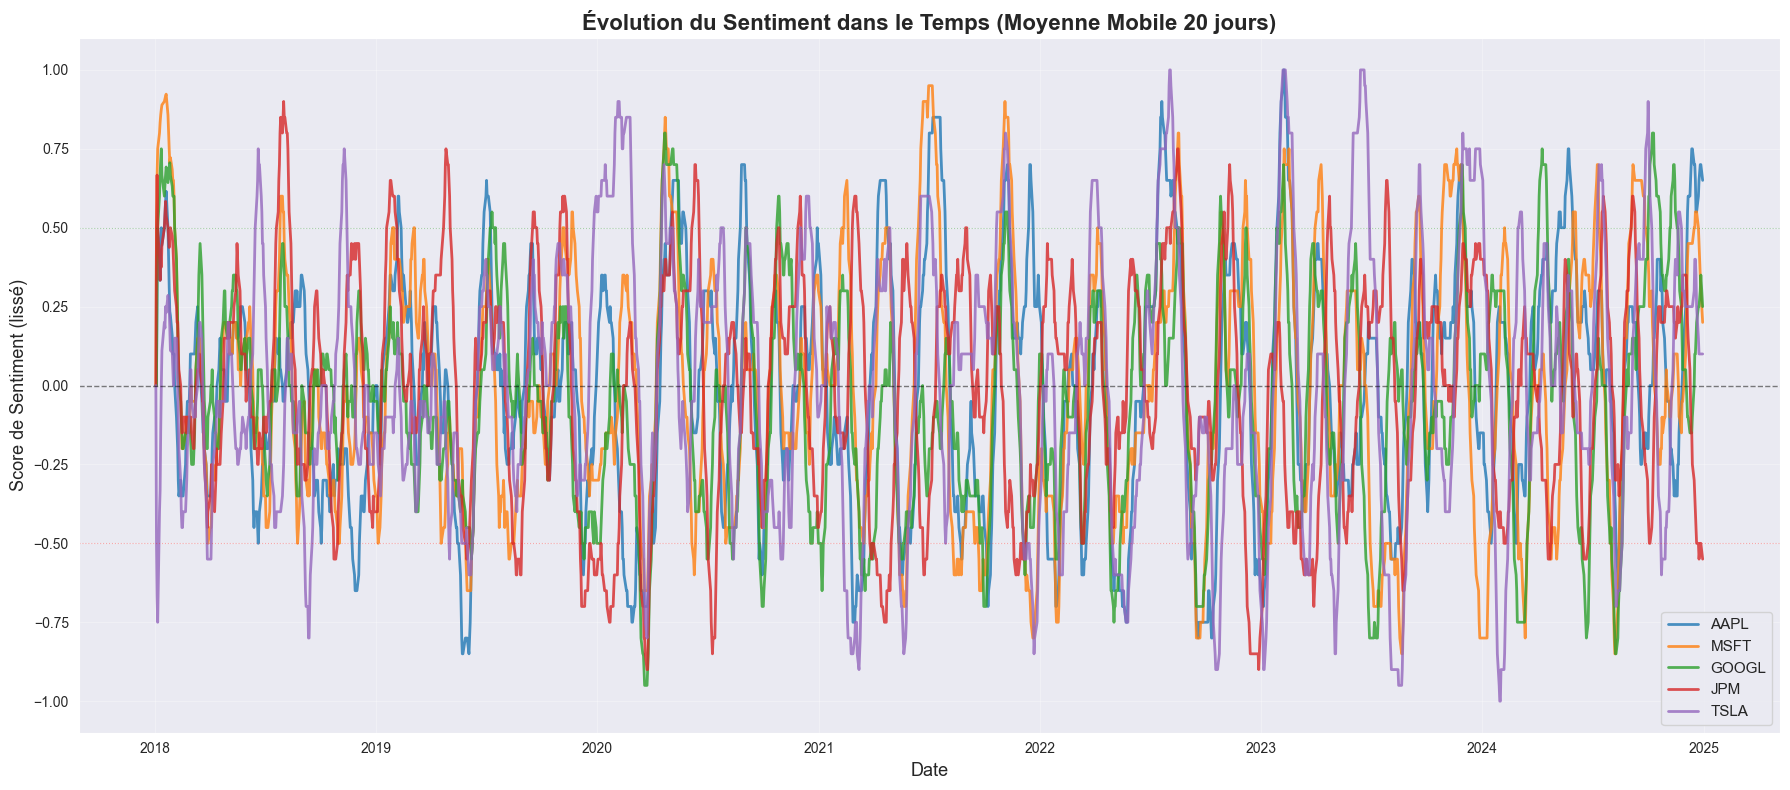

 Graphique 2/4: Évolution temporelle du sentiment


In [37]:
# Visualisation 2: Évolution du sentiment dans le temps (5 tickers)
fig, ax = plt.subplots(figsize=(18, 8))

top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'TSLA']

for ticker in top_tickers:
    ticker_data = data_with_sentiment[data_with_sentiment['Ticker'] == ticker].copy()
    ticker_data = ticker_data.sort_values('Date')
    
    # Sentiment rolling moyen (20 jours)
    ticker_data['sentiment_smooth'] = ticker_data['sentiment_score'].rolling(20, min_periods=1).mean()
    
    ax.plot(ticker_data['Date'], ticker_data['sentiment_smooth'], 
            label=ticker, linewidth=2, alpha=0.8)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(0.5, color='green', linewidth=0.8, linestyle=':', alpha=0.3)
ax.axhline(-0.5, color='red', linewidth=0.8, linestyle=':', alpha=0.3)

ax.set_title('Évolution du Sentiment dans le Temps (Moyenne Mobile 20 jours)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Score de Sentiment (lissé)', fontsize=13)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Graphique 2/4: Évolution temporelle du sentiment")


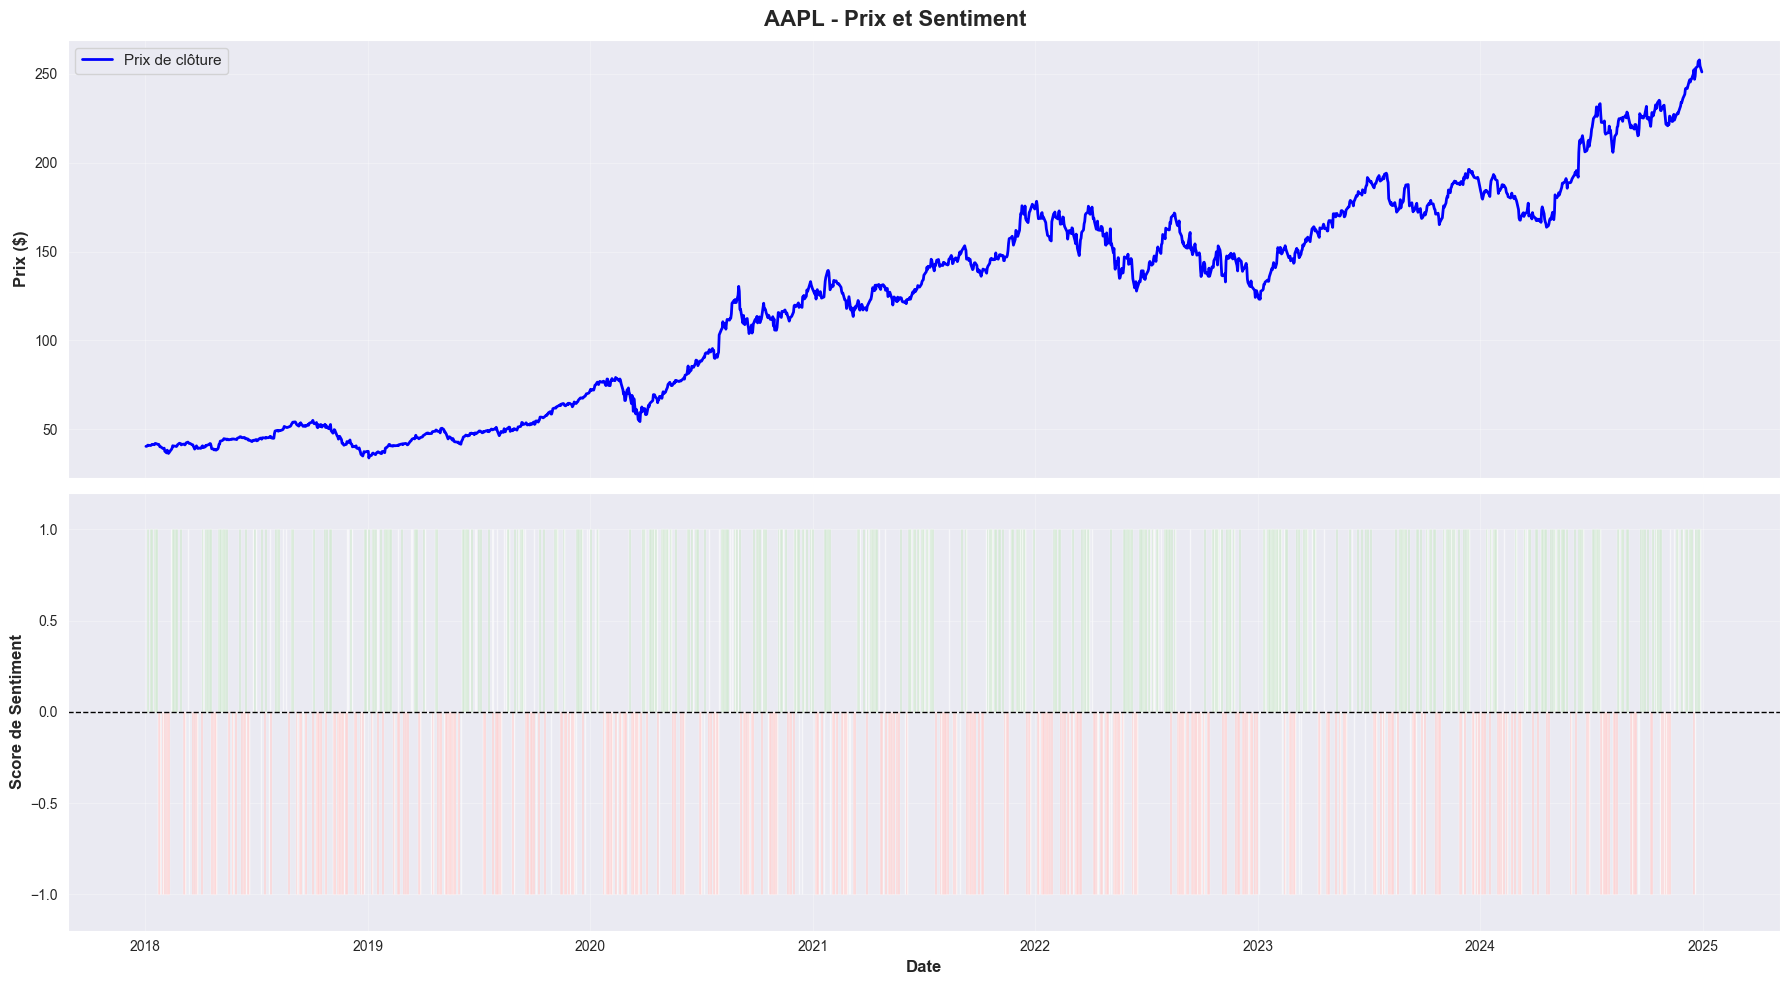

 Graphique 3/4: Prix vs Sentiment pour AAPL


In [38]:
# Visualisation 3: Prix et Sentiment pour un ticker détaillé
sample_ticker = 'AAPL'
ticker_data = data_with_sentiment[data_with_sentiment['Ticker'] == sample_ticker].copy()
ticker_data = ticker_data.sort_values('Date')

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle(f'{sample_ticker} - Prix et Sentiment', fontsize=16, fontweight='bold')

# Panel 1: Prix
axes[0].plot(ticker_data['Date'], ticker_data['Close'], 
             label='Prix de clôture', linewidth=2, color='blue')
axes[0].set_ylabel('Prix ($)', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Panel 2: Sentiment
colors_map = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
colors = ticker_data['sentiment_label'].map(colors_map)
axes[1].bar(ticker_data['Date'], ticker_data['sentiment_score'], 
            color=colors, alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_ylabel('Score de Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[1].set_ylim(-1.2, 1.2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f" Graphique 3/4: Prix vs Sentiment pour {sample_ticker}")


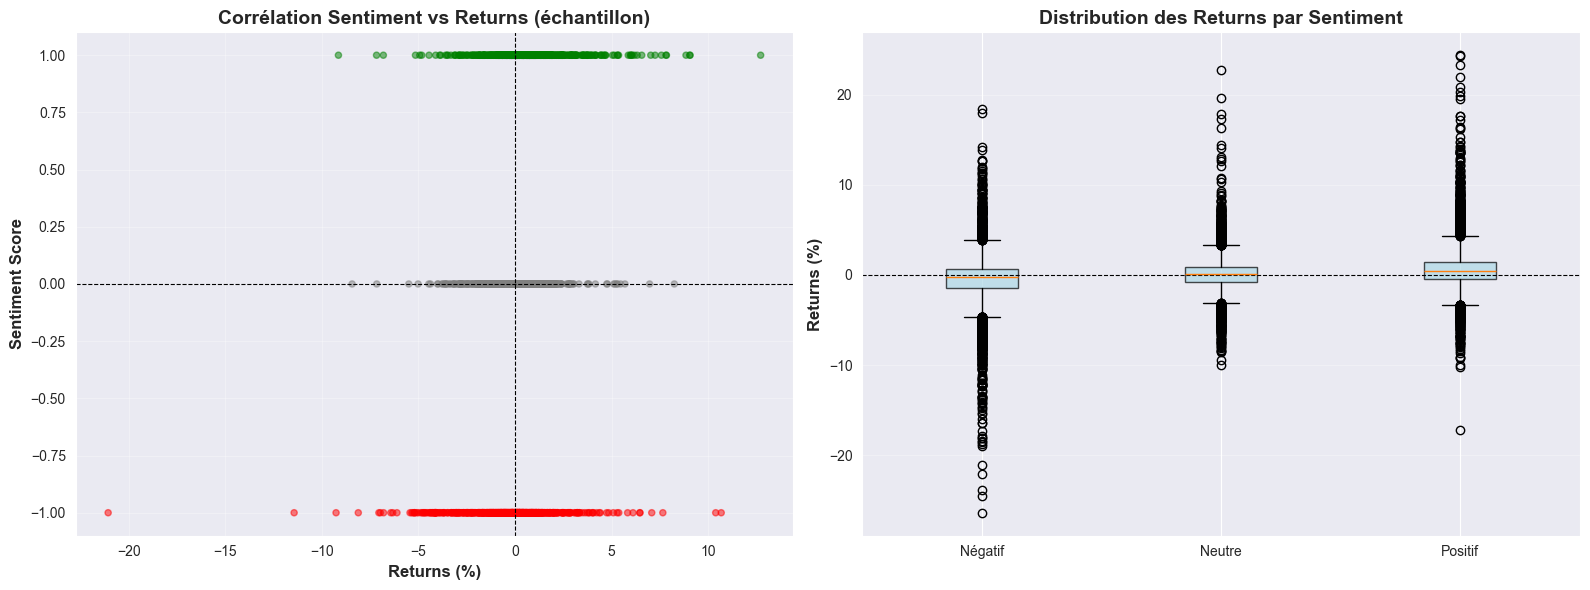

 Graphique 4/4: Corrélation Sentiment/Returns


In [39]:
# Visualisation 4: Corrélation Sentiment vs Returns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Scatter plot (échantillon)
sample_data = data_with_sentiment.dropna(subset=['Returns']).sample(n=min(2000, len(data_with_sentiment)))
colors_scatter = sample_data['sentiment_score'].apply(
    lambda x: 'green' if x > 0 else ('red' if x < 0 else 'gray')
)
axes[0].scatter(sample_data['Returns'] * 100, sample_data['sentiment_score'], 
                c=colors_scatter, alpha=0.5, s=20)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Returns (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sentiment Score', fontsize=12, fontweight='bold')
axes[0].set_title('Corrélation Sentiment vs Returns (échantillon)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Graphique 2: Boxplot par sentiment
data_boxplot = data_with_sentiment.dropna(subset=['Returns']).copy()
data_boxplot['Returns_pct'] = data_boxplot['Returns'] * 100
sentiment_order = ['negative', 'neutral', 'positive']
axes[1].boxplot([data_boxplot[data_boxplot['sentiment_label'] == label]['Returns_pct'] 
                  for label in sentiment_order],
                labels=['Négatif', 'Neutre', 'Positif'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Returns (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution des Returns par Sentiment', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Graphique 4/4: Corrélation Sentiment/Returns")


In [40]:
# Analyse de corrélation
print("\n" + "="*70)
print(" ANALYSE DE CORRÉLATION")
print("="*70)

# Corrélation globale
data_corr = data_with_sentiment.dropna(subset=['Returns'])
corr_global = data_corr[['sentiment_score', 'Returns']].corr().iloc[0, 1]
print(f"\n Corrélation globale Sentiment/Returns: {corr_global:.4f}")

# Corrélation par ticker
print("\n Corrélation par Ticker:")
corr_by_ticker = []
for ticker in sorted(data_with_sentiment['Ticker'].unique()):
    ticker_data = data_with_sentiment[
        (data_with_sentiment['Ticker'] == ticker) & 
        (data_with_sentiment['Returns'].notna())
    ]
    if len(ticker_data) > 10:
        corr = ticker_data[['sentiment_score', 'Returns']].corr().iloc[0, 1]
        corr_by_ticker.append({'Ticker': ticker, 'Corrélation': round(corr, 4)})

corr_df = pd.DataFrame(corr_by_ticker).sort_values('Corrélation', ascending=False)
display(corr_df)

print(f"\n Corrélation moyenne: {corr_df['Corrélation'].mean():.4f}")
print(f" Corrélation min: {corr_df['Corrélation'].min():.4f}")
print(f" Corrélation max: {corr_df['Corrélation'].max():.4f}")
print("="*70)



 ANALYSE DE CORRÉLATION

 Corrélation globale Sentiment/Returns: 0.2156

 Corrélation par Ticker:


,Ticker,Corrélation
14,TSLA,0.2803
11,NVDA,0.2638
6,GOOGL,0.2482
4,CAT,0.2446
9,META,0.2385
1,AMZN,0.2360
2,BA,0.2332
3,BAC,0.2252
12,PFE,0.2230
19,XOM,0.2196



 Corrélation moyenne: 0.2139
 Corrélation min: 0.1591
 Corrélation max: 0.2803


In [41]:
# Vérification de la qualité
print("\n" + "="*70)
print(" VÉRIFICATION DE LA QUALITÉ")
print("="*70)

# Valeurs manquantes
missing = data_with_sentiment[['sentiment_score', 'sentiment_confidence', 'sentiment_label']].isnull().sum()
if missing.sum() == 0:
    print(" Aucune valeur manquante dans les colonnes sentiment")
else:
    print(f"⚠️  Valeurs manquantes détectées:")
    for col, count in missing[missing > 0].items():
        print(f"  - {col}: {count}")

# Distribution par ticker
print("\n DISTRIBUTION PAR TICKER:")
ticker_dist = data_with_sentiment.groupby('Ticker')['sentiment_label'].value_counts().unstack(fill_value=0)
print(f"\n{ticker_dist}")

# Équilibre des classes
class_balance = data_with_sentiment['sentiment_label'].value_counts(normalize=True) * 100
print("\n ÉQUILIBRE DES CLASSES:")
for label, pct in class_balance.items():
    status = "✅" if 25 <= pct <= 40 else "⚠️"
    print(f"  {status} {label.capitalize()}: {pct:.1f}%")

if class_balance.min() >= 25 and class_balance.max() <= 40:
    print("\n Distribution équilibrée (idéale pour ML)")
else:
    print("\n⚠️  Distribution légèrement déséquilibrée")

print("="*70)



 VÉRIFICATION DE LA QUALITÉ
⚠️  Valeurs manquantes détectées:
  - sentiment_confidence: 20

 DISTRIBUTION PAR TICKER:

sentiment_label  negative  neutral  positive
Ticker                                      
AAPL                  603      562       595
AMZN                  620      544       596
BA                    649      405       706
BAC                   549      678       533
CAT                   661      460       639
CVX                   571      601       588
GOOGL                 637      573       550
JNJ                   513      675       572
JPM                   573      636       551
META                  666      397       697
MSFT                  628      530       602
NVDA                  659      503       598
PFE                   465      788       507
T                     482      818       460
TSLA                  703      350       707
UNH                   666      486       608
V                     582      622       556
VZ                    439

In [ ]:
# Sauvegarder les données avec sentiment
print("\n" + "="*70)
print("💾 SAUVEGARDE DES DONNÉES")
print("="*70)

output_dir = config.data_dir / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / 'financial_data_with_sentiment.csv'
data_with_sentiment.to_csv(output_path, index=False)

file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"\n✅ Données sauvegardées: {output_path}")
print(f"   Taille: {len(data_with_sentiment):,} lignes × {len(data_with_sentiment.columns)} colonnes ({file_size_mb:.2f} MB)")
print("="*70)


In [42]:
# Sauvegarder les données avec sentiment
print("\n" + "="*70)
print("💾 SAUVEGARDE DES DONNÉES")
print("="*70)

output_dir = config.data_dir / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / 'financial_data_with_sentiment.csv'
data_with_sentiment.to_csv(output_path, index=False)

file_size_mb = output_path.stat().st_size / (1024 * 1024)

print(f"\n✅ Données sauvegardées: {output_path}")
print(f"   Taille: {len(data_with_sentiment):,} lignes × {len(data_with_sentiment.columns)} colonnes ({file_size_mb:.2f} MB)")
print("="*70)



💾 SAUVEGARDE DES DONNÉES

✅ Données sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\processed\financial_data_with_sentiment.csv
   Taille: 35,200 lignes × 18 colonnes (9.13 MB)
